<a href="https://colab.research.google.com/github/dohaalnabahin/Data_science_and_machine_learning_Journey/blob/main/Preparing_Non_Uniform_Time_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os
#import tick customization tools
import matplotlib.ticker as mticks
import matplotlib.dates as mdates
## Setting figures to timeseries-friendly
plt.rcParams['figure.figsize'] = (12,4)
plt.rcParams['figure.facecolor'] = 'white'
sns.set_context("talk", font_scale=0.9)
# set random seed
SEED = 321
np.random.seed(SEED)
#display more columns
pd.set_option('display.max_columns',50)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/05-IntermediateML/Part1_Crime_Beta_3880953751259285714.csv', low_memory=False)

df.head()

,RowID,CCNumber,CrimeDateTime,CrimeCode,Description,Inside_Outside,Weapon,Post,Gender,Age,Race,Ethnicity,Location,Old_District,New_District,Neighborhood,Latitude,Longitude,GeoLocation,PremiseType,Total_Incidents,x,y
0,1,14I10336,8/29/2014 12:00:00 PM,5A,BURGLARY,NaN,NaN,835,M,52.0,UNKNOWN,NaN,2700 W FAIRMOUNT AVE,SOUTHWEST,NaN,SHIPLEY HILL,39.288352,-76.660731,"(39.288352111548775,-76.660731200606335)",ROW/TOWNHOUSE-VAC,1,-76.660731,39.288352
1,2,14H13075,8/29/2014 11:45:00 PM,4E,COMMON ASSAULT,NaN,NaN,515,F,24.0,BLACK_OR_AFRICAN_AMERICAN,NaN,500 E 38TH ST,NORTHERN,NaN,WAVERLY,39.335514,-76.607897,"(39.335514488267016,-76.60789683728612)",ROW/TOWNHOUSE-OCC,1,-76.607897,39.335514
2,3,14H13066,8/29/2014 11:10:00 PM,6G,LARCENY,NaN,NaN,114,F,44.0,BLACK_OR_AFRICAN_AMERICAN,NaN,200 PARK AVE,CENTRAL,NaN,DOWNTOWN,39.292553,-76.618255,"(39.292552601970897,-76.618254674552134)",BAR,1,-76.618255,39.292553
3,4,14I00593,8/29/2014 7:00:00 AM,6J,LARCENY,NaN,NaN,732,NaN,NaN,UNKNOWN,NaN,1700 GWYNNS FALLS PKWY,WESTERN,NaN,PARKVIEW/WOODBROOK,39.316814,-76.649890,"(39.316813840390076,-76.649889876952656)",STREET,1,-76.649890,39.316814
4,5,14H13360,8/29/2014 11:30:00 PM,6G,LARCENY,NaN,NaN,213,F,26.0,WHITE,NaN,900 S BOND ST,SOUTHEAST,NaN,FELLS POINT,39.280805,-76.594750,"(39.28080478810265,-76.594749640946659)",BAR,1,-76.594750,39.280805


In [4]:
test_date = df.loc[0, 'CrimeDateTime']
test_date

'8/29/2014 12:00:00 PM'

In [5]:
test_datetime = pd.to_datetime(test_date)
test_datetime

Timestamp('2014-08-29 12:00:00')

In [6]:
# df['CrimeDateTime'] = pd.to_datetime(df['CrimeDateTime'])

In [7]:
df['CrimeDateTime'] = pd.to_datetime(df['CrimeDateTime'],errors='coerce')

In [8]:
# how many null values did we create?
df['CrimeDateTime'].isna().sum()

np.int64(4)

In [9]:
# drop the single erroneous time
df = df.dropna(subset=['CrimeDateTime'])
df['CrimeDateTime'].isna().sum()

np.int64(0)

In [10]:
## now that we remove NaT's let's make our datetime index
df = df.set_index('CrimeDateTime')
df.head(3)

,RowID,CCNumber,CrimeCode,Description,Inside_Outside,Weapon,Post,Gender,Age,Race,Ethnicity,Location,Old_District,New_District,Neighborhood,Latitude,Longitude,GeoLocation,PremiseType,Total_Incidents,x,y
CrimeDateTime,,,,,,,,,,,,,,,,,,,,,,
2014-08-29 12:00:00,1,14I10336,5A,BURGLARY,NaN,NaN,835,M,52.0,UNKNOWN,NaN,2700 W FAIRMOUNT AVE,SOUTHWEST,NaN,SHIPLEY HILL,39.288352,-76.660731,"(39.288352111548775,-76.660731200606335)",ROW/TOWNHOUSE-VAC,1,-76.660731,39.288352
2014-08-29 23:45:00,2,14H13075,4E,COMMON ASSAULT,NaN,NaN,515,F,24.0,BLACK_OR_AFRICAN_AMERICAN,NaN,500 E 38TH ST,NORTHERN,NaN,WAVERLY,39.335514,-76.607897,"(39.335514488267016,-76.60789683728612)",ROW/TOWNHOUSE-OCC,1,-76.607897,39.335514
2014-08-29 23:10:00,3,14H13066,6G,LARCENY,NaN,NaN,114,F,44.0,BLACK_OR_AFRICAN_AMERICAN,NaN,200 PARK AVE,CENTRAL,NaN,DOWNTOWN,39.292553,-76.618255,"(39.292552601970897,-76.618254674552134)",BAR,1,-76.618255,39.292553


In [11]:
df = df.sort_index()
df.index

DatetimeIndex(['1720-08-14 02:00:02', '1730-09-03 17:30:02',
               '1900-05-06 19:00:00', '1920-06-18 01:30:00',
               '1922-06-22 13:00:00', '1928-09-26 10:00:00',
               '1930-10-29 08:50:00', '1963-10-30 00:00:00',
               '1966-01-01 01:00:00', '1969-07-20 21:00:00',
               ...
               '2024-12-29 21:50:00', '2024-12-29 21:50:00',
               '2024-12-29 22:18:00', '2024-12-29 22:18:00',
               '2024-12-29 22:27:00', '2024-12-29 23:19:00',
               '2024-12-29 23:19:00', '2024-12-29 23:19:00',
               '2024-12-29 23:19:00', '2024-12-29 23:50:00'],
              dtype='datetime64[ns]', name='CrimeDateTime', length=644733, freq=None)

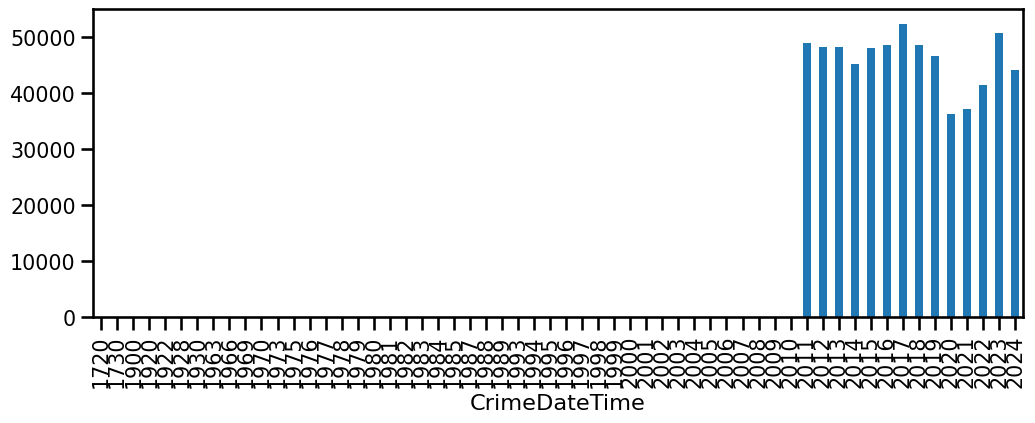

In [12]:
years = df.index.year
years.value_counts().sort_index().plot(kind='bar');

In [13]:
## keeping 2011 to present
df = df.loc['2011':]
df.index

DatetimeIndex(['2011-01-01 00:00:00', '2011-01-01 00:00:00',
               '2011-01-01 00:00:00', '2011-01-01 00:01:00',
               '2011-01-01 00:01:00', '2011-01-01 00:05:00',
               '2011-01-01 00:05:00', '2011-01-01 00:05:00',
               '2011-01-01 00:10:00', '2011-01-01 00:15:00',
               ...
               '2024-12-29 21:50:00', '2024-12-29 21:50:00',
               '2024-12-29 22:18:00', '2024-12-29 22:18:00',
               '2024-12-29 22:27:00', '2024-12-29 23:19:00',
               '2024-12-29 23:19:00', '2024-12-29 23:19:00',
               '2024-12-29 23:19:00', '2024-12-29 23:50:00'],
              dtype='datetime64[ns]', name='CrimeDateTime', length=644531, freq=None)

<Axes: ylabel='Description'>

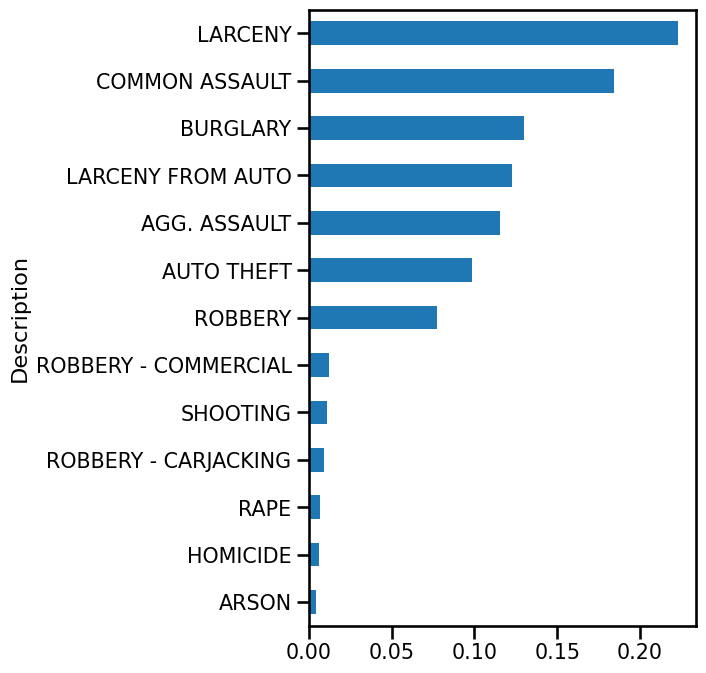

In [14]:
## Inspect the value_counts for the different types of crimes
crime_counts = df['Description'].value_counts(normalize=True)
crime_counts.sort_values().plot(kind='barh',figsize=(5,8))

In [15]:
## Inspect the value_counts for the different types of crimes
crime_counts = df['Description'].value_counts().to_frame('Total # of Crimes')
crime_counts

,Total # of Crimes
Description,
LARCENY,143737
COMMON ASSAULT,118901
BURGLARY,83650
LARCENY FROM AUTO,79075
AGG. ASSAULT,74314
AUTO THEFT,63512
ROBBERY,49966
ROBBERY - COMMERCIAL,7680
SHOOTING,7068


In [16]:
# display with an inline-barplot inside your df
crime_counts.style.bar('Total # of Crimes')

,Total # of Crimes
Description,
LARCENY,143737
COMMON ASSAULT,118901
BURGLARY,83650
LARCENY FROM AUTO,79075
AGG. ASSAULT,74314
AUTO THEFT,63512
ROBBERY,49966
ROBBERY - COMMERCIAL,7680
SHOOTING,7068


##Using Dictionaries and Loops to Prepare Time Series

In [17]:
## demoing groupby with .counts() vs .size()
df.groupby("Description").count().head()

,RowID,CCNumber,CrimeCode,Inside_Outside,Weapon,Post,Gender,Age,Race,Ethnicity,Location,Old_District,New_District,Neighborhood,Latitude,Longitude,GeoLocation,PremiseType,Total_Incidents,x,y
Description,,,,,,,,,,,,,,,,,,,,,
AGG. ASSAULT,74314,74314,74314,5362,73916,73366,71306,69716,73251,16754,73755,65299,8088,73282,74151,74151,74314,67957,74314,74151,74151
ARSON,2715,2715,2715,125,2295,2666,2019,1605,2515,297,2703,2460,207,2666,2706,2706,2715,2525,2715,2706,2706
AUTO THEFT,63512,63512,63512,5994,82,62549,57540,56364,59607,18910,63058,49832,12734,62480,63344,63344,63512,60791,63512,63344,63344
BURGLARY,83650,83650,83650,3128,233,83196,63982,58487,78860,7726,83379,78160,5037,83156,83590,83590,83650,78799,83650,83590,83590
COMMON ASSAULT,118901,118901,118901,9787,31625,117653,114351,110336,116966,27143,118279,103380,14282,117423,118721,118721,118901,109525,118901,118721,118721


In [18]:
df.groupby("Description").size().head()

,0
Description,
AGG. ASSAULT,74314
ARSON,2715
AUTO THEFT,63512
BURGLARY,83650
COMMON ASSAULT,118901


##Testing 1 crime first

In [19]:
## making our dictionary
CRIMES = {}

In [20]:
## Lets test 1 crime before we create our loop
crime ='ROBBERY'
crime

'ROBBERY'

In [21]:
# I. Save a temp df of just the rows that match the crime
temp = df.loc[ df['Description']==crime]
temp.head(3)

,RowID,CCNumber,CrimeCode,Description,Inside_Outside,Weapon,Post,Gender,Age,Race,Ethnicity,Location,Old_District,New_District,Neighborhood,Latitude,Longitude,GeoLocation,PremiseType,Total_Incidents,x,y
CrimeDateTime,,,,,,,,,,,,,,,,,,,,,,
2011-01-01 02:45:00,148396,11A00126,3AF,ROBBERY,NaN,FIREARM,321,M,22.0,BLACK_OR_AFRICAN_AMERICAN,NaN,600 BROADWAY,EASTERN,NaN,DUNBAR-BROADWAY,39.297281,-76.593187,"(39.297280769197286,-76.593186538999191)",STREET,1,-76.593187,39.297281
2011-01-01 04:25:00,150512,11A00157,3B,ROBBERY,NaN,NaN,532,F,23.0,BLACK_OR_AFRICAN_AMERICAN,NaN,2500 EDGECOMBE CIR N,NORTHERN,NaN,PARKLANE,39.343027,-76.658458,"(39.343026766436168,-76.658457961938751)",APT/CONDO - OCCUPIED,1,-76.658458,39.343027
2011-01-01 04:55:00,148039,11A00161,3B,ROBBERY,NaN,NaN,212,M,55.0,BLACK_OR_AFRICAN_AMERICAN,NaN,1400 E FAYETTE ST,SOUTHEAST,NaN,DUNBAR-BROADWAY,39.292969,-76.598510,"(39.292968763700166,-76.598509626981652)",STREET,1,-76.598510,39.292969


In [22]:
# II. Resample the temp DataFrame as Daily data (crime counts)
# and keep ONLY the .size()
temp_res = temp.resample("D").size()
temp_res

,0
CrimeDateTime,
2011-01-01,5
2011-01-02,10
2011-01-03,9
2011-01-04,4
2011-01-05,6
...,...
2024-12-25,8
2024-12-26,5
2024-12-27,4


In [23]:
#III. Save the temporary DataFrame in the dictionary, #using the crime description as the key.
CRIMES[crime] = temp_res.copy()
CRIMES.keys()

dict_keys(['ROBBERY'])

In [24]:
CRIMES['ROBBERY']

,0
CrimeDateTime,
2011-01-01,5
2011-01-02,10
2011-01-03,9
2011-01-04,4
2011-01-05,6
...,...
2024-12-25,8
2024-12-26,5
2024-12-27,4


##Making Our Loop

In [25]:
# 1. get list of  unique crime descriptions
crime_list = df['Description'].unique()
crime_list

array(['LARCENY', 'RAPE', 'AGG. ASSAULT', 'LARCENY FROM AUTO', 'BURGLARY',
       'COMMON ASSAULT', 'AUTO THEFT', 'ROBBERY', 'ROBBERY - COMMERCIAL',
       'ARSON', 'ROBBERY - CARJACKING', 'HOMICIDE', 'SHOOTING'],
      dtype=object)

In [26]:
# 2. Create an empty dictionary
CRIMES = {}
# 3. Loop through the list of crimes
for crime in crime_list:
    # I. Save a temp df of just the rows that match the crime
   temp = df.loc[ df['Description']==crime].copy()
    # II. Resample the temp DataFrame as Daily data (crime counts)
    # and keep ONLY the .size()
   temp_res = temp.resample("D").size()
   #III. Save the temporary DataFrame in the dictionary,
   #using the crime description as the key.
   CRIMES[crime] = temp_res.copy()
CRIMES.keys()

dict_keys(['LARCENY', 'RAPE', 'AGG. ASSAULT', 'LARCENY FROM AUTO', 'BURGLARY', 'COMMON ASSAULT', 'AUTO THEFT', 'ROBBERY', 'ROBBERY - COMMERCIAL', 'ARSON', 'ROBBERY - CARJACKING', 'HOMICIDE', 'SHOOTING'])

In [27]:
CRIMES['SHOOTING']

,0
CrimeDateTime,
2012-01-20,1
2012-01-21,0
2012-01-22,0
2012-01-23,0
2012-01-24,0
...,...
2024-12-25,0
2024-12-26,2
2024-12-27,5


##Convert Dictionary to DataFrame

In [28]:
crimes_df = pd.DataFrame(CRIMES)
crimes_df

,LARCENY,RAPE,AGG. ASSAULT,LARCENY FROM AUTO,BURGLARY,COMMON ASSAULT,AUTO THEFT,ROBBERY,ROBBERY - COMMERCIAL,ARSON,ROBBERY - CARJACKING,HOMICIDE,SHOOTING
CrimeDateTime,,,,,,,,,,,,,
2011-01-01,39,5,28,27,21,41,15,5,2,1.0,NaN,NaN,NaN
2011-01-02,20,2,6,20,19,14,5,10,1,0.0,NaN,NaN,NaN
2011-01-03,19,1,13,16,21,15,7,9,1,0.0,NaN,NaN,NaN
2011-01-04,29,1,11,12,12,29,10,4,0,0.0,NaN,NaN,NaN
2011-01-05,30,0,9,14,28,26,10,6,2,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-25,15,0,13,8,5,32,1,8,4,1.0,1.0,0.0,0.0
2024-12-26,21,0,13,10,5,23,4,5,1,0.0,2.0,1.0,2.0
2024-12-27,20,0,14,6,7,19,8,4,1,2.0,0.0,1.0,5.0


In [29]:
## saving to disk for later
crimes_df.to_csv("baltimore_crime_counts_2023.csv")

#**Timezones**

In [42]:

df = pd.read_csv(
    "/content/baltimore_crime_counts_2023.csv",
    parse_dates=["CrimeDateTime"],
    index_col=0
)

df.index

DatetimeIndex(['2011-01-01', '2011-01-02', '2011-01-03', '2011-01-04',
               '2011-01-05', '2011-01-06', '2011-01-07', '2011-01-08',
               '2011-01-09', '2011-01-10',
               ...
               '2024-12-20', '2024-12-21', '2024-12-22', '2024-12-23',
               '2024-12-24', '2024-12-25', '2024-12-26', '2024-12-27',
               '2024-12-28', '2024-12-29'],
              dtype='datetime64[ns]', name='CrimeDateTime', length=5112, freq=None)

In [43]:
df.index = pd.to_datetime(df.index, errors="coerce", utc=True)

df = df[~df.index.isna()]
df = df.sort_index()

df.index

DatetimeIndex(['2011-01-01 00:00:00+00:00', '2011-01-02 00:00:00+00:00',
               '2011-01-03 00:00:00+00:00', '2011-01-04 00:00:00+00:00',
               '2011-01-05 00:00:00+00:00', '2011-01-06 00:00:00+00:00',
               '2011-01-07 00:00:00+00:00', '2011-01-08 00:00:00+00:00',
               '2011-01-09 00:00:00+00:00', '2011-01-10 00:00:00+00:00',
               ...
               '2024-12-20 00:00:00+00:00', '2024-12-21 00:00:00+00:00',
               '2024-12-22 00:00:00+00:00', '2024-12-23 00:00:00+00:00',
               '2024-12-24 00:00:00+00:00', '2024-12-25 00:00:00+00:00',
               '2024-12-26 00:00:00+00:00', '2024-12-27 00:00:00+00:00',
               '2024-12-28 00:00:00+00:00', '2024-12-29 00:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='CrimeDateTime', length=5112, freq=None)

In [44]:
df = df.resample("D").asfreq()
df.head(3)

,LARCENY,RAPE,AGG. ASSAULT,LARCENY FROM AUTO,BURGLARY,COMMON ASSAULT,AUTO THEFT,ROBBERY,ROBBERY - COMMERCIAL,ARSON,ROBBERY - CARJACKING,HOMICIDE,SHOOTING
CrimeDateTime,,,,,,,,,,,,,
2011-01-01 00:00:00+00:00,39,5,28,27,21,41,15,5,2,1.0,NaN,NaN,NaN
2011-01-02 00:00:00+00:00,20,2,6,20,19,14,5,10,1,0.0,NaN,NaN,NaN
2011-01-03 00:00:00+00:00,19,1,13,16,21,15,7,9,1,0.0,NaN,NaN,NaN


In [45]:
ts0 = df.index[0]
ts0

Timestamp('2011-01-01 00:00:00+0000', tz='UTC')

In [46]:
ts0.astimezone("US/Eastern")

Timestamp('2010-12-31 19:00:00-0500', tz='US/Eastern')

In [47]:
ts0.astimezone("US/Pacific")

Timestamp('2010-12-31 16:00:00-0800', tz='US/Pacific')

In [48]:
df = df.tz_convert(None)
df.head(3)

,LARCENY,RAPE,AGG. ASSAULT,LARCENY FROM AUTO,BURGLARY,COMMON ASSAULT,AUTO THEFT,ROBBERY,ROBBERY - COMMERCIAL,ARSON,ROBBERY - CARJACKING,HOMICIDE,SHOOTING
CrimeDateTime,,,,,,,,,,,,,
2011-01-01,39,5,28,27,21,41,15,5,2,1.0,NaN,NaN,NaN
2011-01-02,20,2,6,20,19,14,5,10,1,0.0,NaN,NaN,NaN
2011-01-03,19,1,13,16,21,15,7,9,1,0.0,NaN,NaN,NaN


#**Binning Time Series**

In [49]:
# Set options
pd.set_option('display.max_columns',100)
# Customize figure style for stakeholder-facing visualizations
plt.style.use(('ggplot','fivethirtyeight'))
sns.set_context('notebook', font_scale=1.2)
plt.rcParams['figure.figsize'] = (12,4)
plt.rcParams['savefig.transparent'] = False
plt.rcParams['savefig.bbox'] = 'tight'

In [50]:
df = pd.read_csv("/content/drive/MyDrive/AXSOSACADEMY/05-IntermediateML/Part1_Crime_Beta_3880953751259285714.csv",
                 low_memory=False)
## Converting crimedatetime and coercing errors
df['CrimeDateTime'] = pd.to_datetime(df['CrimeDateTime'], errors='coerce')
df = df.dropna(subset=['CrimeDateTime'])
## setting and sorting the index
df = df.set_index("CrimeDateTime")
df = df.sort_index()
df.head(3)

,RowID,CCNumber,CrimeCode,Description,Inside_Outside,Weapon,Post,Gender,Age,Race,Ethnicity,Location,Old_District,New_District,Neighborhood,Latitude,Longitude,GeoLocation,PremiseType,Total_Incidents,x,y
CrimeDateTime,,,,,,,,,,,,,,,,,,,,,,
1720-08-14 02:00:02,149031,23H06330,6F,LARCENY,NaN,NaN,124,F,39.0,BLACK_OR_AFRICAN_AMERICAN,UNKNOWN,800 MC ALEER CT,CENTRAL,NaN,OLDTOWN,39.300101,-76.605440,"(39.300101,-76.60544)",OTHER/RESIDENTIAL,1,-76.605440,39.300101
1730-09-03 17:30:02,149030,23I01590,6J,LARCENY,NaN,NaN,934,F,0.0,WHITE,UNKNOWN,10 E HENRIETTA ST,SOUTHERN,NaN,FEDERAL HILL,39.279043,-76.614148,"(39.279043,-76.614148)",STREET,1,-76.614148,39.279043
1900-05-06 19:00:00,149029,23E02187,5B,BURGLARY,NaN,NaN,932,NaN,NaN,NaN,NaN,900 W BARRE ST,SOUTHERN,NaN,WASHINGTON VILLAGE/PIGTOWN,39.282617,-76.627416,"(39.282617,-76.627416)",SPECIALTY STORE,1,-76.627416,39.282617


In [54]:
drop_cols = ['RowID', 'CCNO', 'CCNumber', 'Post', 'GeoLocation', 'Location', 'Premise']

df = df.drop(columns=drop_cols, errors='ignore')

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 644733 entries, 1720-08-14 02:00:02 to 2024-12-29 23:50:00
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   CrimeCode        644733 non-null  object 
 1   Description      644733 non-null  object 
 2   Inside_Outside   44415 non-null   object 
 3   Weapon           169866 non-null  object 
 4   Gender           541678 non-null  object 
 5   Age              520790 non-null  float64
 6   Race             612190 non-null  object 
 7   Ethnicity        117469 non-null  object 
 8   Old_District     566409 non-null  object 
 9   New_District     70269 non-null   object 
 10  Neighborhood     635806 non-null  object 
 11  Latitude         643406 non-null  float64
 12  Longitude        643406 non-null  float64
 13  PremiseType      592864 non-null  object 
 14  Total_Incidents  644733 non-null  int64  
 15  x                643406 non-null  float64
 16  y   

##Feature Engineering & Initial EDA

###Datetime components

In [55]:
## saving just the date (no time) as a column
df['Date'] = df.index.date
# could also use .strftime + pd.to_datetime
# df['Date'] = pd.to_datetime(df.index.strftime('%Y-%m-%d'))
df.head(3)

,CrimeCode,Description,Inside_Outside,Weapon,Gender,Age,Race,Ethnicity,Old_District,New_District,Neighborhood,Latitude,Longitude,PremiseType,Total_Incidents,x,y,Date
CrimeDateTime,,,,,,,,,,,,,,,,,,
1720-08-14 02:00:02,6F,LARCENY,NaN,NaN,F,39.0,BLACK_OR_AFRICAN_AMERICAN,UNKNOWN,CENTRAL,NaN,OLDTOWN,39.300101,-76.605440,OTHER/RESIDENTIAL,1,-76.605440,39.300101,1720-08-14
1730-09-03 17:30:02,6J,LARCENY,NaN,NaN,F,0.0,WHITE,UNKNOWN,SOUTHERN,NaN,FEDERAL HILL,39.279043,-76.614148,STREET,1,-76.614148,39.279043,1730-09-03
1900-05-06 19:00:00,5B,BURGLARY,NaN,NaN,NaN,NaN,NaN,NaN,SOUTHERN,NaN,WASHINGTON VILLAGE/PIGTOWN,39.282617,-76.627416,SPECIALTY STORE,1,-76.627416,39.282617,1900-05-06


#Year

In [56]:
## Engineering Features using components of the date/time
df['Year']  = df.index.year

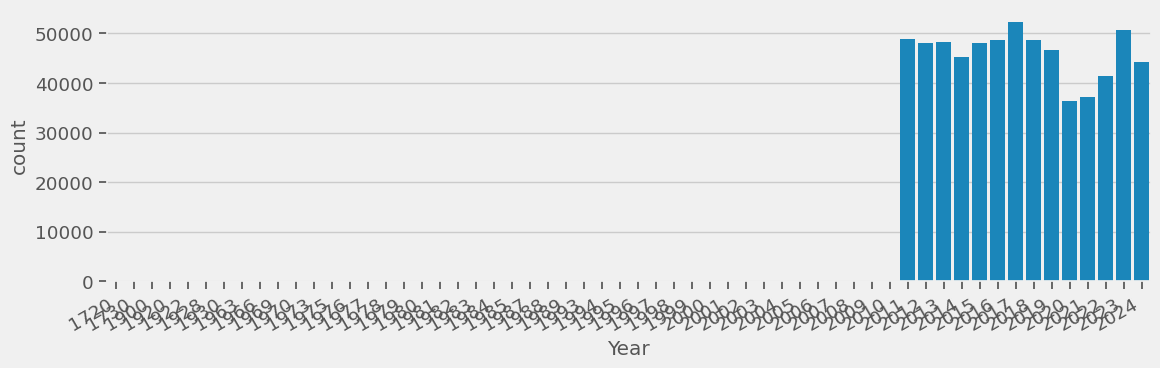

In [57]:
## Visualize years
ax = sns.countplot(data=df, x='Year')
fig = ax.get_figure()
fig.autofmt_xdate()

In [58]:
df['Year'].value_counts().sort_index(ascending = False).head(15)

,count
Year,
2024,44139
2023,50745
2022,41443
2021,37186
2020,36305
2019,46598
2018,48592
2017,52291
2016,48618


In [59]:
## keeping data from yr 2011 to present
df = df.loc['2011':'2022'].copy()

/tmp/ipykernel_2152/247088404.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Year',palette='dark');


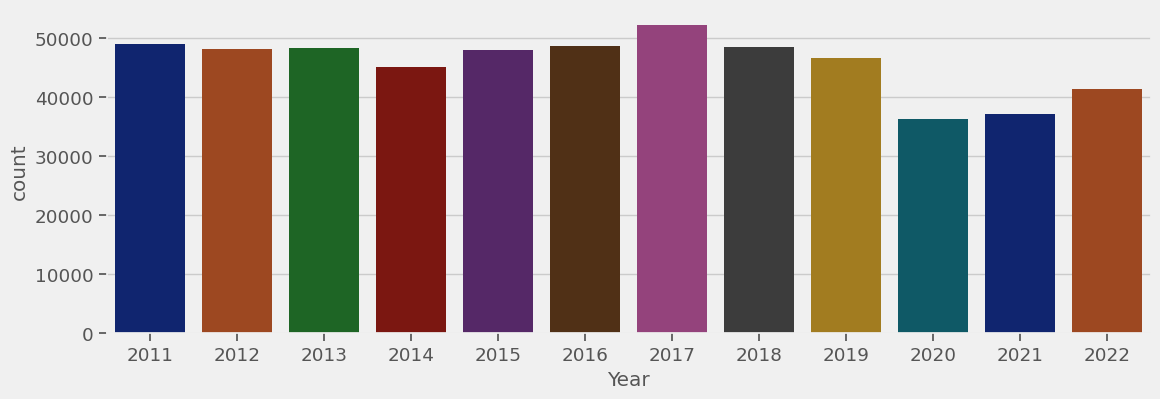

In [60]:
## visualizing again with years removed
sns.countplot(data=df, x='Year',palette='dark');

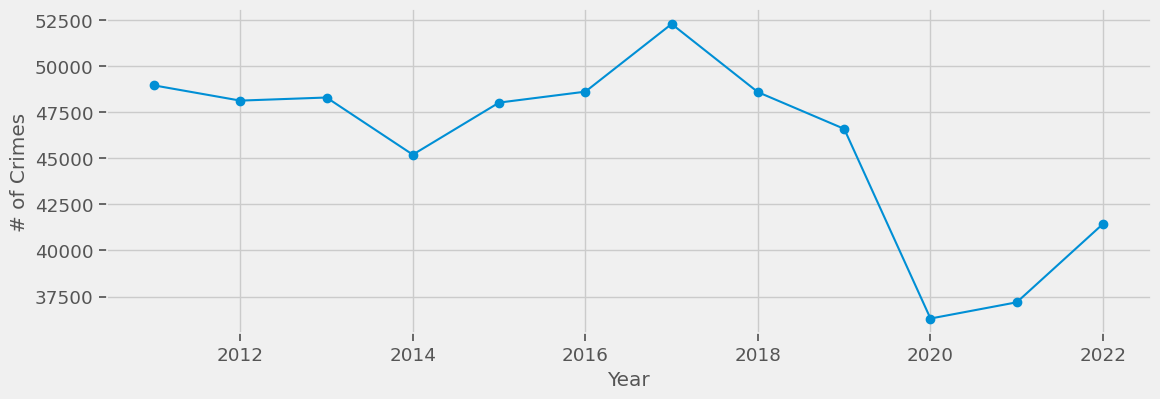

In [61]:
## save year counts
year_counts = df['Year'].value_counts().sort_index()
year_counts.plot(style='o-',grid=True,ylabel='# of Crimes', xlabel='Year');

#Month

In [62]:
## Extracting the Month
df['Month'] = df.index.month
df['MonthName'] = df.index.month_name()
df.head(3)

,CrimeCode,Description,Inside_Outside,Weapon,Gender,Age,Race,Ethnicity,Old_District,New_District,Neighborhood,Latitude,Longitude,PremiseType,Total_Incidents,x,y,Date,Year,Month,MonthName
CrimeDateTime,,,,,,,,,,,,,,,,,,,,,
2011-01-01,6G,LARCENY,NaN,NaN,F,26.0,WHITE,NaN,SOUTHERN,NaN,FEDERAL HILL,39.277040,-76.613389,TAVERN/NIGHT CLUB,1,-76.613389,39.277040,2011-01-01,2011,1,January
2011-01-01,6E,LARCENY,NaN,NaN,M,44.0,BLACK_OR_AFRICAN_AMERICAN,NaN,WESTERN,NaN,MOSHER,39.295738,-76.661591,STREET,1,-76.661591,39.295738,2011-01-01,2011,1,January
2011-01-01,2A,RAPE,NaN,OTHER,M,16.0,BLACK_OR_AFRICAN_AMERICAN,NaN,WESTERN,NaN,HARLEM PARK,39.298875,-76.639342,NaN,1,-76.639342,39.298875,2011-01-01,2011,1,January


In [63]:
# saving lookup for number vs name
unique_months = df.drop_duplicates(subset=['Month']).sort_values('Month')
month_lookup =dict(zip(unique_months['Month'],unique_months['MonthName']))
month_lookup

{1: 'January',
 2: 'February',
 3: 'March',
 4: 'April',
 5: 'May',
 6: 'June',
 7: 'July',
 8: 'August',
 9: 'September',
 10: 'October',
 11: 'November',
 12: 'December'}

/tmp/ipykernel_2152/1369714036.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='MonthName',palette='dark',order=month_lookup.values());
/tmp/ipykernel_2152/1369714036.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');


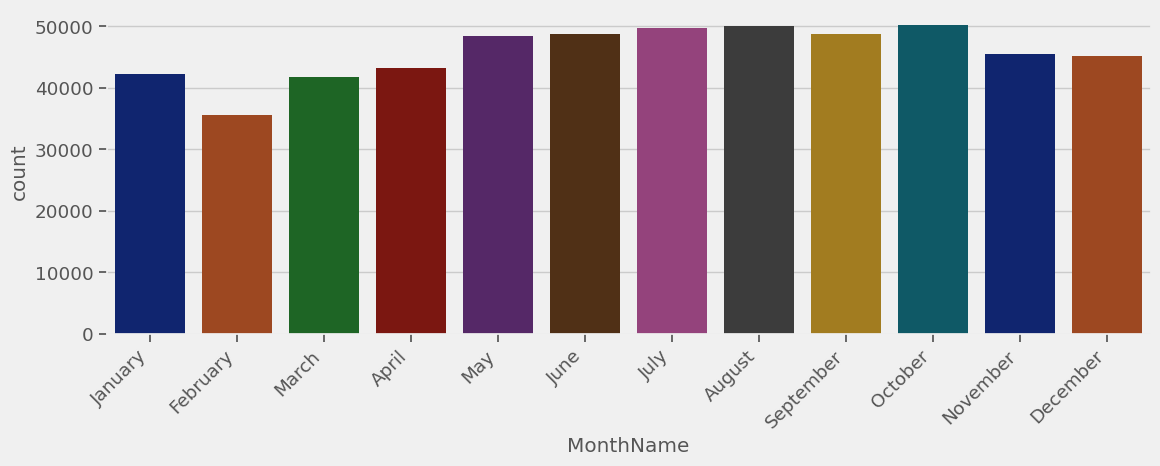

In [64]:
ax = sns.countplot(data=df, x='MonthName',palette='dark',order=month_lookup.values());
# Rotate xtick labels and align the text to the bar
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');

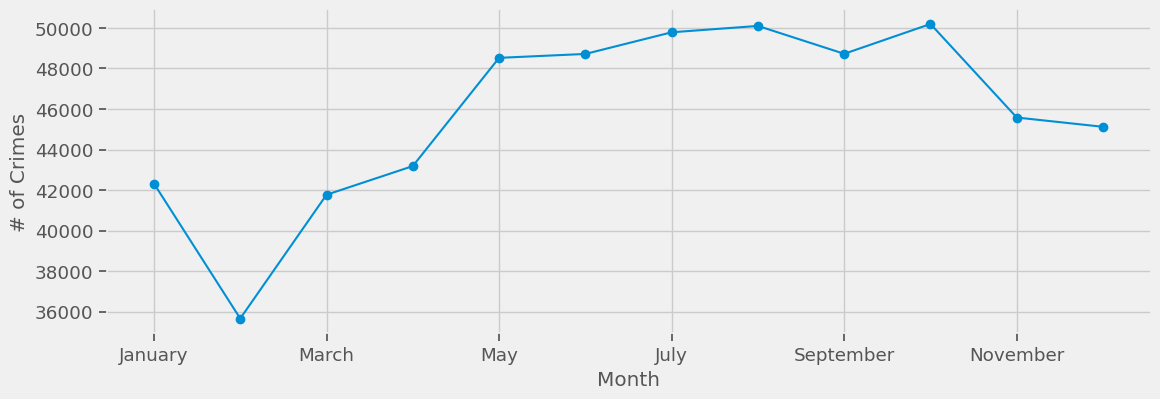

In [65]:
## save month counts
month_counts = df['MonthName'].value_counts()[month_lookup.values()]
# year_counts = df.groupby("Year").size()
ax = month_counts.plot(style='o-',grid=True,
                       ylabel='# of Crimes',
                       xlabel='Month');

#Day of Week

In [66]:
## adding day of week as both number & name
df['DayOfWeek'] = df.index.day_name()
df['DayNum'] = df.index.day_of_week
df.head(3)

,CrimeCode,Description,Inside_Outside,Weapon,Gender,Age,Race,Ethnicity,Old_District,New_District,Neighborhood,Latitude,Longitude,PremiseType,Total_Incidents,x,y,Date,Year,Month,MonthName,DayOfWeek,DayNum
CrimeDateTime,,,,,,,,,,,,,,,,,,,,,,,
2011-01-01,6G,LARCENY,NaN,NaN,F,26.0,WHITE,NaN,SOUTHERN,NaN,FEDERAL HILL,39.277040,-76.613389,TAVERN/NIGHT CLUB,1,-76.613389,39.277040,2011-01-01,2011,1,January,Saturday,5
2011-01-01,6E,LARCENY,NaN,NaN,M,44.0,BLACK_OR_AFRICAN_AMERICAN,NaN,WESTERN,NaN,MOSHER,39.295738,-76.661591,STREET,1,-76.661591,39.295738,2011-01-01,2011,1,January,Saturday,5
2011-01-01,2A,RAPE,NaN,OTHER,M,16.0,BLACK_OR_AFRICAN_AMERICAN,NaN,WESTERN,NaN,HARLEM PARK,39.298875,-76.639342,NaN,1,-76.639342,39.298875,2011-01-01,2011,1,January,Saturday,5


In [67]:
# saving lookup for number vs named days
unique_days = df.drop_duplicates(subset=['DayNum']).sort_values('DayNum')
day_lookup =dict(zip(unique_days['DayNum'],unique_days['DayOfWeek']))
day_lookup

{0: 'Monday',
 1: 'Tuesday',
 2: 'Wednesday',
 3: 'Thursday',
 4: 'Friday',
 5: 'Saturday',
 6: 'Sunday'}

/tmp/ipykernel_2152/4279422870.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='DayNum',palette='dark')
/tmp/ipykernel_2152/4279422870.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([v for k,v in day_lookup.items()]);


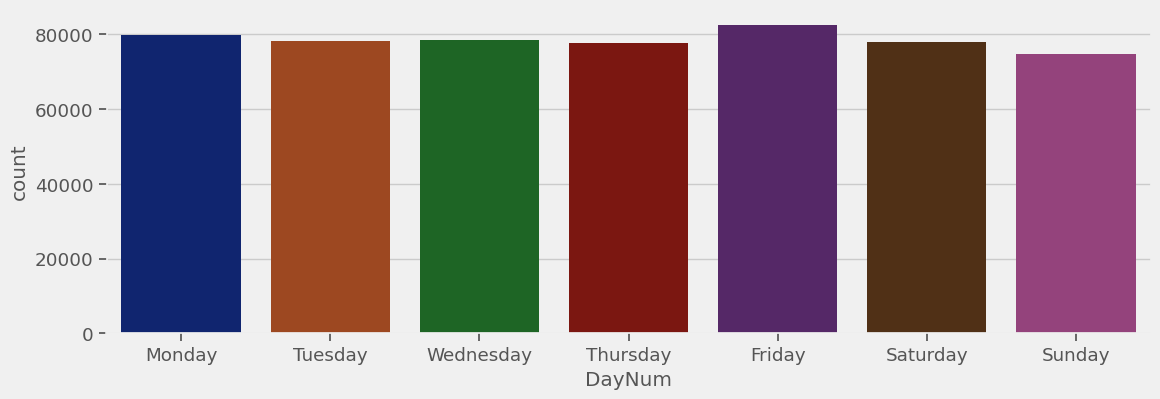

In [69]:
## plot DayNum, but use names from day_lookup for ticks
ax = sns.countplot(data=df, x='DayNum',palette='dark')
ax.set_xticklabels([v for k,v in day_lookup.items()]);

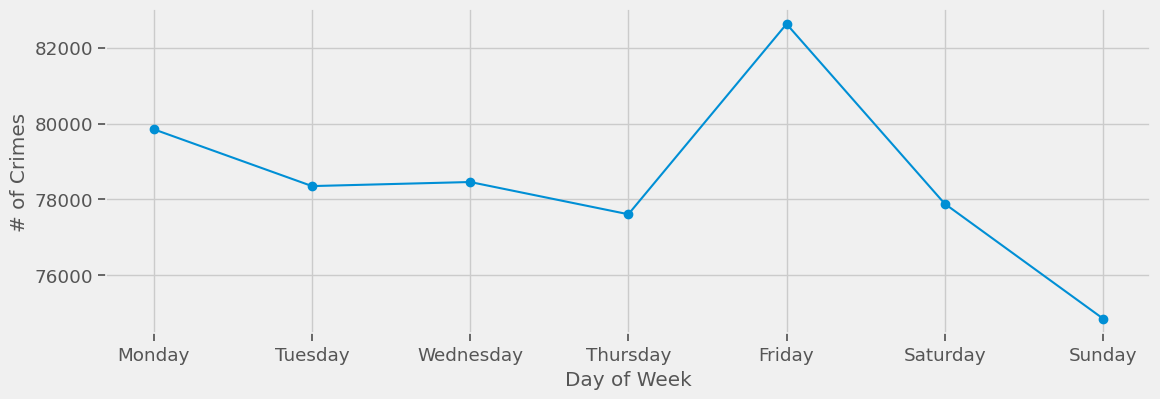

In [70]:
## save day counts
day_counts = df['DayNum'].value_counts().sort_index()
## now that its in order, rename using day_lookup
day_counts = day_counts.rename(day_lookup)
ax = day_counts.plot(style='o-',grid=True,ylabel='# of Crimes', xlabel='Day of Week')

#Weekend

/tmp/ipykernel_2152/474510420.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Weekend',palette='dark');


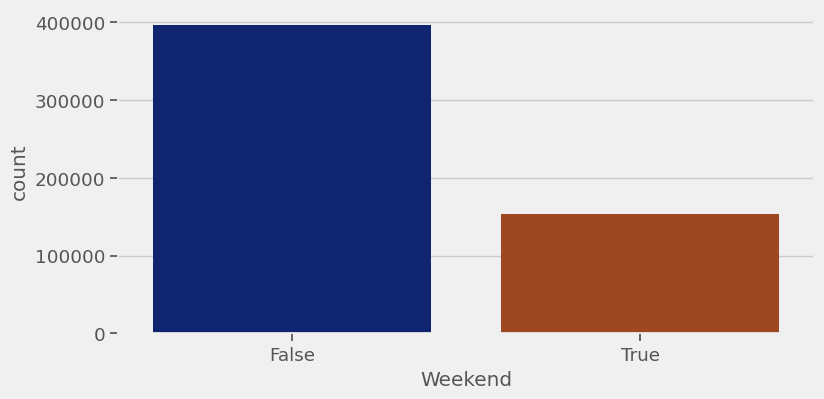

In [71]:
df['Weekend'] = df['DayOfWeek'].isin(['Saturday','Sunday'])
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Weekend',palette='dark');

In [72]:
## calculating value counts and then dividing week days by 5 and weekend by 2
weekend_counts = df["Weekend"].value_counts()
weekend_counts.loc[False] /= 5
weekend_counts.loc[True] /= 2
weekend_counts

/tmp/ipykernel_2152/484230828.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '79378.6' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  weekend_counts.loc[False] /= 5


,count
Weekend,
False,79378.6
True,76377.0


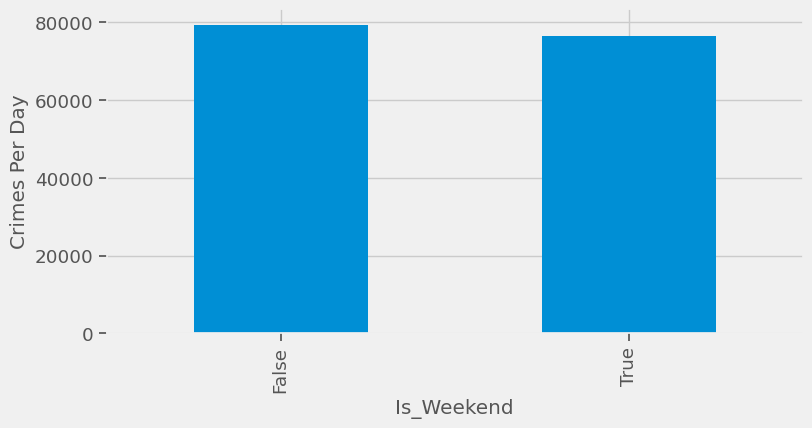

In [73]:
ax = weekend_counts.plot(kind='bar',figsize=(8,4))
ax.set(ylabel='Crimes Per Day', xlabel='Is_Weekend');

#Hour of the Day

/tmp/ipykernel_2152/19206046.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='HourOfDay',palette='dark');


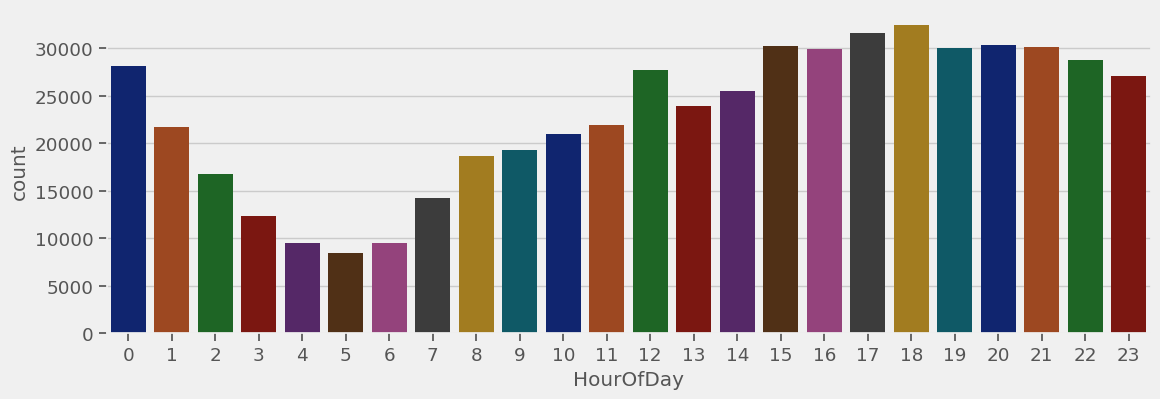

In [74]:
# adding hour of the day (12am=0)
df['HourOfDay'] = df.index.hour
sns.countplot(data=df, x='HourOfDay',palette='dark');

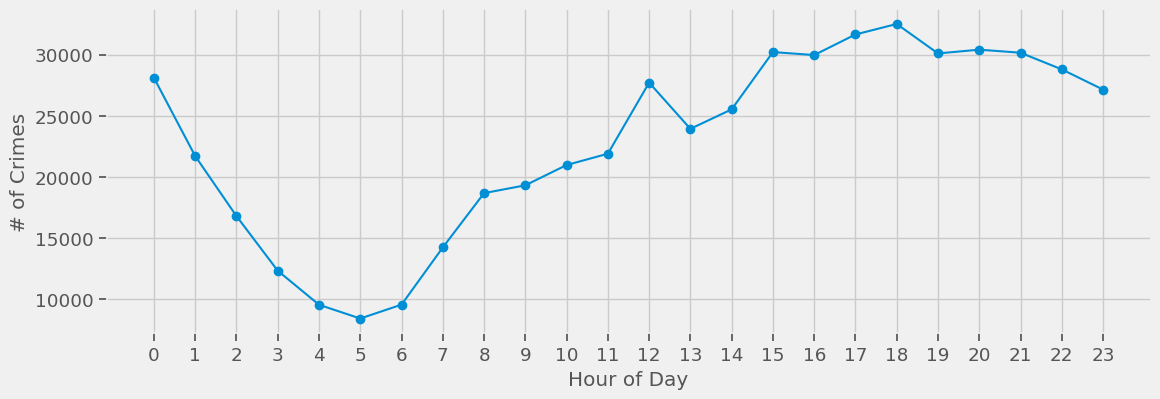

In [75]:
## save hour counts
hour_counts = df['HourOfDay'].value_counts().sort_index()
# year_counts = df.groupby("Year").size()
ax = hour_counts.plot(style='o-',grid=True,ylabel='# of Crimes', xlabel='Hour of Day',xticks=hour_counts.index);